# Previous Gaussian mixture and all-active conditional bimodal target

The left panel uses the corrected fixed-parameter `exp5` Gaussian mixture. The right panel uses the project all-active extension of `IzbickiBimodalFullDGP`; its two-dimensional case reproduces `plot_bimodal_illustration.py` from the public repository accompanying *Benchmarking Tabular Foundation Models for Conditional Density Estimation in Regression*.

For $d>2$, all coordinates of $X\sim\mathcal{N}(0,I_d)$ enter two normalized dense orthogonal projections. The public two-component formulas are applied to those projections, so every context dimension affects the means, scales, and mixture probability without increasing the target scale mechanically with $d$.

Source: [rizbicki/tabDensityComparisons](https://github.com/rizbicki/tabDensityComparisons/blob/fab6559adfa1a5fe45224f89baf209e276819382/plot_bimodal_illustration.py).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

from benchmark_izbicki_2026_bimodal_newsvendor import IzbickiBimodalFullDGP
from synthetic_fixed_dgp import make_toy_mixture_parameters, makettoy_multi_exp

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 8,
    'figure.dpi': 130,
})

N = 2000
D = 9
K = 5
OLD_PARAMETER_SEED = 32
OLD_SAMPLE_SEED = 33
BIMODAL_SAMPLE_SEED = 42
CRITICAL_RATIO = 0.95

OUTPUT_DIR = Path('analysis_outputs/synthetic_target_dgp_comparison')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Generate both targets

Both generators are reproducible from their sample seeds. Every context dimension is active in the conditional bimodal target.

In [2]:
old_parameters = make_toy_mixture_parameters(
    num_features=D,
    random_state=OLD_PARAMETER_SEED,
    num_exps=K,
    noise_scale=10.0,
)
old_data, _ = makettoy_multi_exp(
    num_samples=N,
    num_features=D,
    random_state=OLD_PARAMETER_SEED,
    num_exps=K,
    sample_random_state=OLD_SAMPLE_SEED,
    parameters=old_parameters,
)
old_y = old_data[:, -2]
old_component = old_data[:, -1].astype(int)

bimodal_dgp = IzbickiBimodalFullDGP(context_dim=D)
bimodal_x, bimodal_y_column, bimodal_component = bimodal_dgp.sample(
    N, seed=BIMODAL_SAMPLE_SEED, return_component=True
)
bimodal_y = bimodal_y_column[:, 0]
bimodal_component = bimodal_component.astype(int)

summary = pd.DataFrame([
    {
        'generator': 'Corrected fixed exp5 DGP',
        'context_dim': D,
        'active_context_dim': D,
        'mean': old_y.mean(),
        'std': old_y.std(),
        'minimum': old_y.min(),
        'median': np.median(old_y),
        'p95': np.quantile(old_y, CRITICAL_RATIO),
        'maximum': old_y.max(),
    },
    {
        'generator': 'All-active conditional bimodal DGP',
        'context_dim': D,
        'active_context_dim': D,
        'mean': bimodal_y.mean(),
        'std': bimodal_y.std(),
        'minimum': bimodal_y.min(),
        'median': np.median(bimodal_y),
        'p95': np.quantile(bimodal_y, CRITICAL_RATIO),
        'maximum': bimodal_y.max(),
    },
])
summary.round(3)

,generator,context_dim,active_context_dim,mean,std,minimum,median,p95,maximum
0,Corrected fixed exp5 DGP,9,9,74.366,103.520,-59.331,41.588,308.255,331.486
1,All-active conditional bimodal DGP,9,9,0.608,1.723,-5.330,0.563,3.536,8.639


## One-row target comparison

The panels use separate horizontal axes because the source DGPs have different target units. Colors show sampled mixture components, the black line is the marginal KDE, and the dashed line is the marginal 95th percentile used by the new conditional-bimodal newsvendor interface.

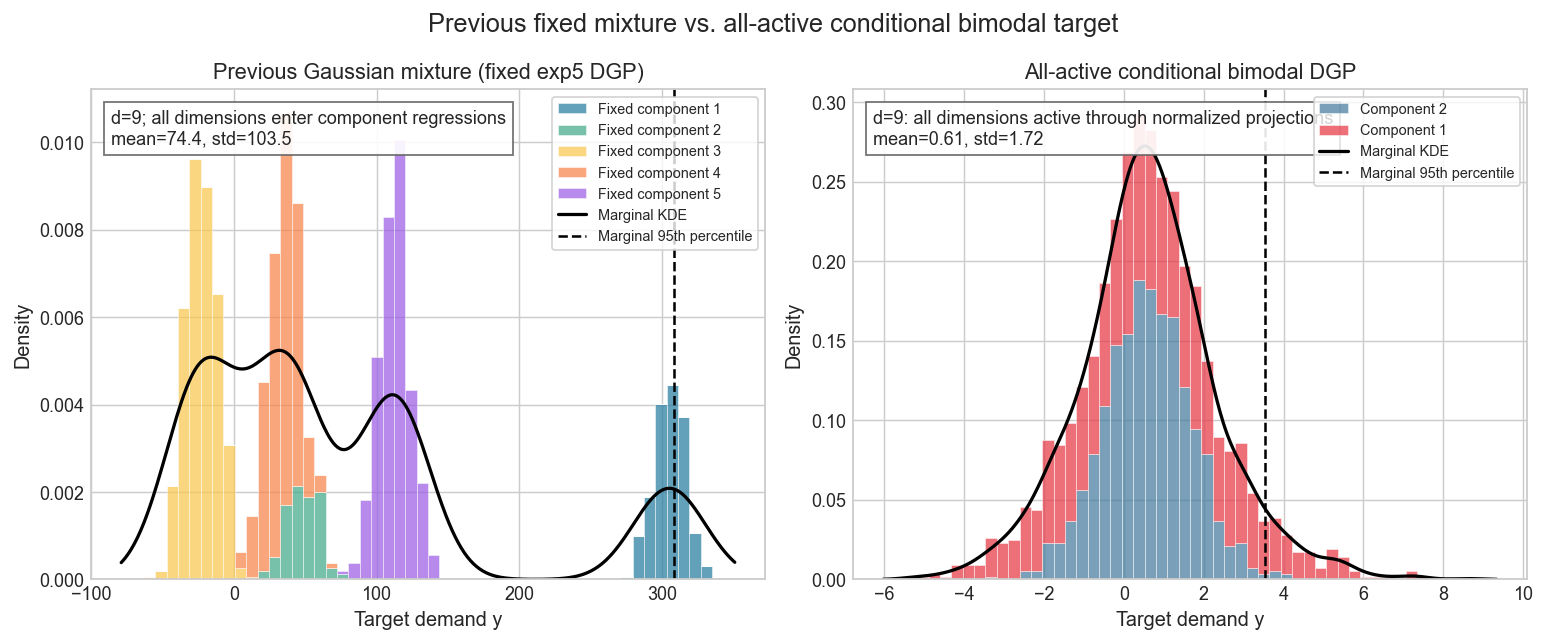

Saved figure to /Users/seinzhou/Desktop/wsc_newexp/analysis_outputs/synthetic_target_dgp_comparison/fixed_exp5_vs_izbicki_all_active_bimodal.png


In [3]:
def plot_component_density(ax, target, labels, names, colors):
    margin = max(0.05 * np.ptp(target), 1e-6)
    bins = np.linspace(target.min() - margin, target.max() + margin, 55)
    groups = [target[labels == index] for index in range(len(names))]
    bin_width = bins[1] - bins[0]
    weights = [
        np.full(len(group), 1.0 / (len(target) * bin_width))
        for group in groups
    ]
    ax.hist(
        groups, bins=bins, weights=weights, stacked=True, color=colors,
        alpha=0.72, edgecolor='white', linewidth=0.35, label=names,
    )
    density_grid = np.linspace(bins[0], bins[-1], 600)
    ax.plot(
        density_grid, gaussian_kde(target)(density_grid),
        color='black', linewidth=1.8, label='Marginal KDE',
    )
    ax.axvline(
        np.quantile(target, CRITICAL_RATIO), color='black', linestyle='--',
        linewidth=1.4, label='Marginal 95th percentile',
    )
    ax.set_xlabel('Target demand y')
    ax.legend(loc='upper right', frameon=True)

figure, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

plot_component_density(
    axes[0], old_y, old_component,
    [f'Fixed component {index + 1}' for index in range(K)],
    ['#277DA1', '#43AA8B', '#F9C74F', '#F9844A', '#9B5DE5'],
)
axes[0].set_title('Previous Gaussian mixture (fixed exp5 DGP)')
axes[0].set_ylabel('Density')
axes[0].text(
    0.03, 0.96,
    f'd={D}; all dimensions enter component regressions\n'
    + f'mean={old_y.mean():.1f}, std={old_y.std():.1f}',
    transform=axes[0].transAxes, va='top',
    bbox={'facecolor': 'white', 'edgecolor': '#666666', 'alpha': 0.9},
)

plot_component_density(
    axes[1], bimodal_y, bimodal_component,
    ['Component 2', 'Component 1'], ['#457B9D', '#E63946'],
)
axes[1].set_title('All-active conditional bimodal DGP')
axes[1].set_ylabel('Density')
axes[1].text(
    0.03, 0.96,
    f'd={D}: all dimensions active through normalized projections\n'
    + f'mean={bimodal_y.mean():.2f}, std={bimodal_y.std():.2f}',
    transform=axes[1].transAxes, va='top',
    bbox={'facecolor': 'white', 'edgecolor': '#666666', 'alpha': 0.9},
)

figure.suptitle('Previous fixed mixture vs. all-active conditional bimodal target', fontsize=14)
figure.tight_layout()
figure_path = OUTPUT_DIR / 'fixed_exp5_vs_izbicki_all_active_bimodal.png'
figure.savefig(figure_path, dpi=220, bbox_inches='tight')
plt.show()
print(f'Saved figure to {figure_path.resolve()}')

## Main structural difference

- **Corrected fixed exp5 DGP:** five globally fixed linear-Gaussian component regressions; every context dimension enters each component mean.
- **All-active conditional bimodal DGP:** two Gaussian components whose means, scales, and mixing probability depend on two normalized dense projections of every context dimension.
- **Relation to the public example:** the two-dimensional case is exact; the all-active higher-dimensional projection is this project's extension.
- **Decision setting:** the three GenDFL sensitivity scripts use underage cost 19 and overage cost 1 for this data interface, giving $\alpha=0.95$. This newsvendor cost is a project adaptation, not part of the conditional-density benchmark paper.